# What is a permafrost probability distribution map?

By combining data on mapped rock glaciers, machine learning algorithms, and topoclimatic factors, we can create maps that predict the probability of permafrost occurrence. Mapped rock glaciers are categorized as intact and relict, indicating presence and absence of permafrost respectively. This binary classification of points, and the information for two topoclimatic variables,  mean annual air temperature (MAAT) and potential incoming solar radiation (PISR), extracted at the mapped locations, serve as training data for the machine learning algorithm. Through this process, the algorithm learns to identify patterns that distinguish areas with permafrost from those where it has disappeared.

# Importing necessary libraries


The first step involves importing essential libraries for various tasks. These libraries handle:
*   Reading input files: We use libraries like Pandas to read data from CSV files.
*   Data analysis and visualization: Libraries like Matplotlib help us create informative plots and graphs.
*   Machine learning: Scikit-learn provides the tools for building and training machine learning models.
*   Image processing: Libraries like NumPy and PIL enable working with images in various formats.
*   Geospatial data: The GDAL library facilitates handling geospatial datasets.


In [12]:
# Importing necessary libraries for  reading input files, analyzing and visualizing data and results

#from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing several functions from the scikit-learn library

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Importing libraries and functions for raster data processing

from osgeo import gdal


from PIL import Image

import warnings
warnings.filterwarnings('ignore')

# library for ggplot like figures
from plotnine import *

# Providing access to the Google Drive


This training utilizes a pre-formatted data set stored in a comma-separated values (.csv) file. To access this data, we'll mount your Google Drive within Google Colab. This process will request permission to access your Gmail account. Granting this permission is necessary to proceed.

In [ ]:
# Mounting the Google Drive
drive.mount('/content/drive')

# Training data

The next step is to read/load the prepared .csv file that consists of a dataset to train the logistic regression model. You have received a folder called ***Permafrost_probability_KU***.
1. Download the folder “Permafrost_probability_KU” using the shared link.
2. Open Gmail account.
3. Open Google Apps icon. This icon appears as a grid of nine small squares (3x3), typically located in the top right corner of the screen, near your profile picture.
4. Open Google Drive by clicking on the Drive Icon.
5. Click on ‘+New’ tab below the Drive icon at the top left corner of the screen.
6. Click on ‘Folder Upload’ option from the drop down menu.
7. Select the downloaded folder “Permafrost_probability_KU” from the link.
8. Then click on Upload.


In [ ]:
# Importing the dataset to train the model
dataset = pd.read_csv('/content/drive/MyDrive/Permafrost_probability_KU/trainingdata.csv')

# Get names of columns for visualization
print(dataset.columns)

# Explore the first few rows of data
dataset.head()

Here, ***RGID*** indicates whether the mapped rock glacier is ***intact (1)*** or ***relict (0)***.  ***final_maat*** is the value of ***mean annual air temperature (MAAT)*** and ***Solar_radi*** is the value of ***potential incoming solar radiation (PISR)*** recorded at the mapped rock glacier points.

# Rearrange training data

The training data is arranged in such a way that the logistic regression model can be trained. Predictor variables (MAAT and PISR) are collectively defined as variable 'X'. Corresponding RGID values for each set of MAAT and PISR indicating intact and relict rock glaciers are defined as 'y'.

In [ ]:
X = dataset.iloc[:,[0,1]].values
y = dataset.iloc[:,2].values

The enitre data is split into four parts: ***X_train***, ***X_test***, ***y_train***, and ***y_test***. After splitting, 75% of the total data is used in training the logistic regression model and 25% is reserved for testing the accuracy.

In [ ]:
# Splitting the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)



# Standardization of training and test data set

Before feeding data into many machine learning models, it's crucial to standardize the numerical values of all input variables. This pre-processing step ensures all variables are on a similar scale.

In our permafrost mapping project, we're working with two predictor variables, MAAT and PISR, that have vastly different value ranges. To address this difference and ensure all variables contribute equally, we standardize the datasets, transforming their values to a fixed range.

We achieve this standardization using the .fit_transform function from the StandardScaler class within Scikit-learn's sklearn.preprocessing package. This function standardizes both the training and test datasets.

In [ ]:
# Standardize training and test data
sc_X = StandardScaler()
X_train_standardized = sc_X.fit_transform(X_train)
X_test_standardized = sc_X.transform(X_test)


# Logistic regression model

***Logistic regression: Predicting Probabilities with Odds***

Logistic regression is a machine learning tool that estimates the chance, or probability, of something happening. It assumes this probability is related to a combination of one or more independent variables, also known as predictors.

To understand how logistic regression works, we need to introduce the concept of log-odds. It's a fancy way of saying the natural logarithm of the odds ratio, often shortened to "logit." But before diving into log-odds, let's break down probability and odds ratio.

***Probability: The Chance of Something Happening***

Imagine flipping a coin. The probability of heads (success) is 50%, and the probability of tails (failure) is also 50%. Probability simply tells us how likely something is to occur.

***Odds Ratio: Comparing Success vs. Failure***

Odds ratio goes a step further. It compares the likelihood of success to the likelihood of failure for a specific event. In our coin toss example, the odds ratio is 1 (50% / 50%) because the chances of heads and tails are equal.

***Log-Odds: Putting Odds on a Scale***

Here's where things get interesting. Log-odds transforms the odds ratio into a continuous value. It uses the natural logarithm (denoted by ln) of the odds ratio. This creates a scale where we can measure the influence of our predictor variables on the probability of an event.

For instance, if the probability of winning an election is 80% (success) and the probability of losing is 20% (failure), the odds ratio is 4 (80% / 20%). The log-odds, ln(4), would be approximately 1.386.

Next, we'll explore some equations used in logistic regression to see how these concepts work together.

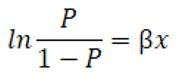


















***Understanding the Logistic Regression Equation***

The logistic regression equation expresses the relationship between the predictor variables and the probability of a specific event. It uses a mathematical function to transform the linear combination of predictors (represented by ***βx***) into a probability value between 0 and 1.

One way to view this equation is through the concept of ***log-odds***. The original equation calculates the natural logarithm ***(ln)*** of the odds ratio ***(P / (1-P))***. Here, ***P*** represents the ***probability of success*** and ***(1-P)*** represents the ***probability of failure***. ***β*** is the coefficient assigned to the predictor variable ***(x)***, which indicates the influence of that variable on the ***log-odds***.

By removing the ln term from the equation, we get a different form that expresses the odds of the event rather than the log-odds. This form is still related to the probability but on a different scale.


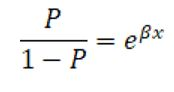




































Here, ***e*** represents the base of the natural logarithm, a mathematical constant approximately equal to 2.718281828459.

Solving the equation leads to a new equation for the probability.

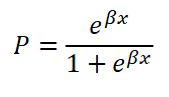






















In general, more than one predictor variable is considered.The term ***βx*** can be written as:








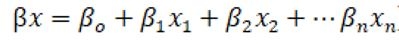




























Here, ***1,2,..,n*** represent ***n*** number of variables and ***β<sub>0</sub>*** represents the ***intercept***.

In this exercise, we use ***binary*** logistic regression model. This means that the model is expected to predict the target variable which is binary: 0 and 1. The model predicts the outcome based on two predictor variables: MAAT and PISR. There can be more than two predictor variables but in this exercise we only consider two commonly used predictor variables to estimate the probability of occurrence of permafrost.

Logistic Regression Model for permafrost probability mapping can be expressed using the following mathematical formula:

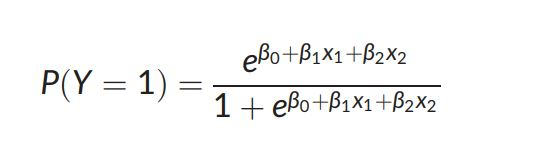


Here, ***P (Y = 1)***, represents the probability of output ***Y*** reaching the
value of 1. The terms ***β<sub>1</sub>*** and ***β<sub>2</sub>***  represent the coefficients of predictor variables ***x<sub>1</sub>*** and ***x<sub>2</sub>*** respectively, ***β<sub>0</sub>***  represents the intercept and ***e*** represents the base of the natural logarithm, approximately equal to 2.718281828459.

# Data and assumptions to train the logistic regression model

In this binary logistic regression analysis, we used data points mapped along the initiation lines of both intact (coded as 1) and relict (coded as 0) rock glaciers. The initiation line represents the starting point where rock glacier movement begins.

Two assumptions were made: points on the initiation line of intact rock glaciers indicate the presence of permafrost, while points on the initiation line of relict rock glaciers suggest its absence.

The presence or absence of permafrost (coded as 1 or 0) at these points is believed to be influenced by the Mean Annual Air Temperature (MAAT) and Potential Incoming Solar Radiation (PISR) values recorded there.

Essentially, the model will learn to predict the presence/absence of permafrost (1/0) based on the MAAT and PISR values. A predicted value of 1 signifies the likely presence of permafrost, while 0 indicates its absence.

Finally, the logistic regression model is trained using the mapped points from intact and relict rock glaciers, along with their corresponding MAAT and PISR values. This means the model is trained on a dataset containing known values for both the dependent variable (presence/absence of permafrost) and the independent variables (MAAT and PISR).

In [ ]:
# Fitting Logistic Regression to the Training Set

classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train_standardized, y_train)

Training the classifier allows us to extract the coefficients for the predictor variables, MAAT and PISR, and the intercept value.

In [ ]:
# Printing the coefficients and the intercept of the Logistic Regression model

print(classifier.coef_, classifier.intercept_)

We can also print the coefficients and the intercept.

In [ ]:
# printing  β1, β2 and β0
print("Coefficient of MAAT (β2) : %.8f, Coefficient of PISR (β1) : %.8f, Intercept (β0): %.8f" % (-2.96136869, -0.5785141, 0.52073968))


# Prediction using the trained model

To evaluate the model's performance, we use a separate test dataset containing known values of 1, 0, MAAT, and PISR. We feed these MAAT and PISR values into the trained model and compare the model's predictions (0 or 1) to the actual permafrost presence/absence labels in the test data.

In [ ]:
# Predicting the Test set results
y_pred = classifier.predict(X_test_standardized)

# Performance of the trained model

To assess the performance of our binary logistic regression model (predicting presence or absence of permafrost coded as 0 and 1, respectively), we use a confusion matrix. This table summarizes the model's accuracy by categorizing its predictions. There are four possible outcomes:

True Positive (TP): The model correctly predicts permafrost presence (1) where it actually exists.
False Positive (FP): The model incorrectly predicts permafrost presence (1) where it's absent (0).
True Negative (TN): The model correctly predicts permafrost absence (0) where it's truly absent.
False Negative (FN): The model incorrectly predicts permafrost absence (0) where it's actually present (1).
Ideally, a good model will have a high number of True Positives and True Negatives, indicating accurate predictions, and low numbers of False Positives and False Negatives.


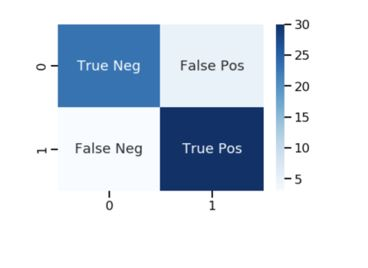

Now, let's create a confusion matrix to visualize how well our model predicts the presence of permafrost in intact and relict rock glaciers.

In [ ]:
# Making the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualizing the confusion matrix
sns.heatmap(cm, annot=True, annot_kws={"size": 16}) # font size
plt.show()


With the model trained and tested, we can now use it to make predictions based on MAAT and PISR data grids.

# Data grids for MAAT and PISR

This exercise reformats MAAT and PISR rasters (previously created .tif files) from location-specific data to cover the entire research area. We read the rasters using ***Image.open*** and ***np.array***, then convert them into single columns using ***.ravel*** for compatibility with our logistic regression model. Rasters are multi-dimensional arrays representing spatial data, and converting them prepares the data for use with the model's two predictor variables (PISR and MAAT).

In [ ]:
#Reading .tif file for MAAT and converting into an array

grid_maat = Image.open('/content/drive/MyDrive/Permafrost_probability_KU/MAAT.tif')
array_maat = np.array(grid_maat)
plt.imshow(array_maat)
plt.colorbar()
plt.show()

#Converting the array into a single column
b_maat = array_maat.ravel()

In [ ]:
#Reading .tif file for PISR and converting into an array

grid_pisr = Image.open('/content/drive/MyDrive/Permafrost_probability_KU/PISR.tif')
array_pisr = np.array(grid_pisr)
plt.imshow(array_pisr)
plt.colorbar()
plt.show()
#Converting the array into a single column
b_pisr = array_pisr.ravel()

Since PISR and MAAT grids have the same size, we stack their one-dimensional arrays using ***column_stack*** to mimic training data. Then, we standardize them using ***.fit_transform*** command in ***StandardScaler*** for optimal logistic regression performance, as our model was trained on standardized data.


In [ ]:
#Stacking the two columns for MAAT and PISR
stack_grids = np.column_stack((b_maat,b_pisr))
sc_stack_grids = sc_X.fit_transform(stack_grids)

# Prediction using grids for predictor variables

With the stacked and standardized predictor variables, we use the ***.predict*** command on our trained classifier. This predicts permafrost presence (1) or absence (0) for each data point, resulting in an array of 0s and 1s.


In [ ]:
#Predicting the probability of permafrost (as 0 and 1) based on MAAT and PISR grids
y_pred_0_1 = classifier.predict(sc_stack_grids)

To obtain probability values, we use ***.predict_proba*** on the stacked and standardized predictors. This provides an array of probabilities (0-1) for both permafrost absence (column 1) and presence (column 2). We split these into separate arrays (***probability_no*** and ***probability_yes***) for clarity.


In [ ]:
# Predicting the probability of permafrost (as values between 0 and 1) based on MAAT and PISR grids
y_pred_probability = classifier.predict_proba(sc_stack_grids)
probability_no = y_pred_probability[:,0]
probability_yes = y_pred_probability[:,1]


We use ***.reshape*** to match the shapes of the probability arrays (***probability_no*** and ***probability_yes***) to the original predictor grids (***array_maat*** and ***array_pisr***).

In [ ]:
# Reshaping the probability values for permafrost absence and permafrost presence
probability_no_reshape = np.reshape(probability_no,(5000,11208))
probability_yes_reshape = np.reshape(probability_yes,(5000,11208))

# Saving probability distribution map as an image file

Finally, we reshape ***probability_no*** and ***probability_yes*** to match the original grids and save them as ***.tif*** files (***Probability_permafrost_presence.tif*** & ***Probability_permafrost_absence.tif***) for further analysis in GIS software (ArcMap/QGIS) or standalone scripts (Python/R). We save these files to your Google Drive using the ***.save*** command.


In [ ]:
# Convert to PIL Image and save
Image.fromarray(probability_no_reshape).save('/content/drive/MyDrive/Permafrost_probability_KU/Probability_permafrost_absence.tif')
Image.fromarray(probability_yes_reshape).save('/content/drive/MyDrive/Permafrost_probability_KU/Probability_permafrost_presence.tif')

Our generated probability map lacks georeferencing, meaning it's a matrix without real-world coordinates. We can address this using existing georeferenced climate data.

While the data lacks coordinates, here's a basic visualization where colors represent probability: yellow indicates high likelihood of permafrost, and dark blue indicates low likelihood.

In [ ]:
# Importing georeferenced and non-georeferenced data set

ds = gdal.Open("/content/drive/MyDrive/Permafrost_probability_KU/MAAT.tif")
gt = ds.GetGeoTransform()
proj = ds.GetProjection()

im_permafrost_presence = Image.open('/content/drive/MyDrive/Permafrost_probability_KU/Probability_permafrost_presence.tif')
array_PP_yes = np.array(im_permafrost_presence)

plt.figure()
plt.imshow(array_PP_yes)
plt.colorbar()
plt.show()


Finally, we need to georeference the permafrost probability grid. We'll use the projection information (***gt*** and ***proj***) extracted from the climate data in the previous step.

Once georeferenced, the grid will be saved to your Google Drive using the ***driver.Create*** function. You can then download and open it in any post-processing software you prefer.

In [ ]:
# Georeferencing and exporting the permafrost probability distribution grid
driver = gdal.GetDriverByName("GTiff")
driver.Register()
outds = driver.Create("/content/drive/MyDrive/Permafrost_probability_KU/Probability_permafrost_presence_georeferenced.tif", xsize = array_PP_yes.shape[1],
                      ysize = array_PP_yes.shape[0], bands = 1,
                      eType = gdal.GDT_Float32)
outds.SetGeoTransform(gt)
outds.SetProjection(proj)
outband = outds.GetRasterBand(1)
outband.WriteArray(array_PP_yes)
outband.SetNoDataValue(np.nan)
outband.FlushCache()

# Closing data set and bands

outband = None
outds = None

<h1 align='center'>THANK YOU</h1>